# Installing Dependencies


In [1]:
%pip install tensorflow numpy pandas scikit-learn matplotlib pillow


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Data Load


## ⚙️ Path Configuration

**Change `BASE_DIR` below to match where you extracted `img.zip`.**

Expected structure after extraction:
```
BASE_DIR/
  img/
    001bd5563b4511f0b16c00155d672fff.png
    d13cde743b4411f0b16c00155d672fff.jpg
    ...
  train-label.csv
  test-label.csv
  submission.csv
```

In [2]:
import os
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────
#  CHANGE THIS to your local path where the dataset lives
# ─────────────────────────────────────────────────────────────
BASE_DIR = '.'          # e.g. '/Users/yourname/Downloads/knu_ml'
IMG_DIR  = os.path.join(BASE_DIR, 'img')  # folder containing all images

TRAIN_LABEL = pd.read_csv(os.path.join(BASE_DIR, 'train-label.csv'), index_col='id')
TEST_LABEL  = pd.read_csv(os.path.join(BASE_DIR, 'test-label.csv'),  index_col='id')

# TRAIN_DATA and TEST_DATA will be loaded as image arrays below
TRAIN_DATA = None   # placeholder – set after preprocessing
TEST_DATA  = None   # placeholder – set after preprocessing

print('Train samples:', len(TRAIN_LABEL))
print('Test  samples:', len(TEST_LABEL))
print('Label distribution (train):')
print(TRAIN_LABEL['label'].value_counts().sort_index())

Train samples: 1385
Test  samples: 1386
Label distribution (train):
label
0    707
1    678
Name: count, dtype: int64


## 1. Imports & Reproducibility

In [3]:
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, Model
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))
print('Metal (Apple Silicon) devices:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPUs available: []
Metal (Apple Silicon) devices: []


## 2. Hyperparameters

In [4]:
# ── Image settings ───────────────────────────────────────────
IMG_HEIGHT   = 160       # larger input → more spatial detail for memes
IMG_WIDTH    = 160
IMG_CHANNELS = 3         # RGB

# ── Training settings ────────────────────────────────────────
BATCH_SIZE   = 32
EPOCHS       = 60        # more epochs; early-stopping & checkpoint guard quality
LR_INIT      = 1e-3
DROPOUT_RATE = 0.4
L2_LAMBDA    = 1e-4
LABEL_SMOOTH = 0.1       # label smoothing prevents overconfident predictions

# ── TTA settings ─────────────────────────────────────────────
TTA_STEPS    = 8         # number of augmented views to average at test time

# ── Validation split ─────────────────────────────────────────
VAL_SPLIT    = 0.15

## 3. Data Loading & Preprocessing

In [5]:
def load_image(filepath: str) -> np.ndarray:
    """Load one image, convert to RGB, resize to (IMG_HEIGHT, IMG_WIDTH)."""
    img = Image.open(filepath).convert('RGB')
    img = img.resize((IMG_WIDTH, IMG_HEIGHT), Image.BILINEAR)
    return np.array(img, dtype=np.float32) / 255.0   # [0, 1] normalisation


def load_dataset(label_df: pd.DataFrame, img_dir: str, has_labels: bool = True):
    """Load all images listed in label_df.
    Returns (X, y) where X is (N, H, W, C) float32, y is (N,) int32 or None.
    """
    images, labels = [], []
    missing = 0
    for row_id, row in label_df.iterrows():
        path = os.path.join(img_dir, row['file'])
        if not os.path.exists(path):
            missing += 1
            continue
        images.append(load_image(path))
        if has_labels:
            labels.append(int(row['label']))
    if missing > 0:
        print(f'  ⚠️  {missing} images not found – skipped')
    X = np.stack(images).astype(np.float32)           # (N, H, W, C)
    y = np.array(labels, dtype=np.int32) if has_labels else None
    return X, y


print('Loading train images …')
X_all, y_all = load_dataset(TRAIN_LABEL, IMG_DIR, has_labels=True)
print(f'  Train shape: {X_all.shape}, labels: {y_all.shape}')

print('Loading test images …')
X_test, _ = load_dataset(TEST_LABEL, IMG_DIR, has_labels=False)
print(f'  Test  shape: {X_test.shape}')

# Assign to template variables
TRAIN_DATA = X_all
TEST_DATA  = X_test

Loading train images …
  Train shape: (1385, 160, 160, 3), labels: (1385,)
Loading test images …
  Test  shape: (1386, 160, 160, 3)


## 4. Exploratory Visualisation

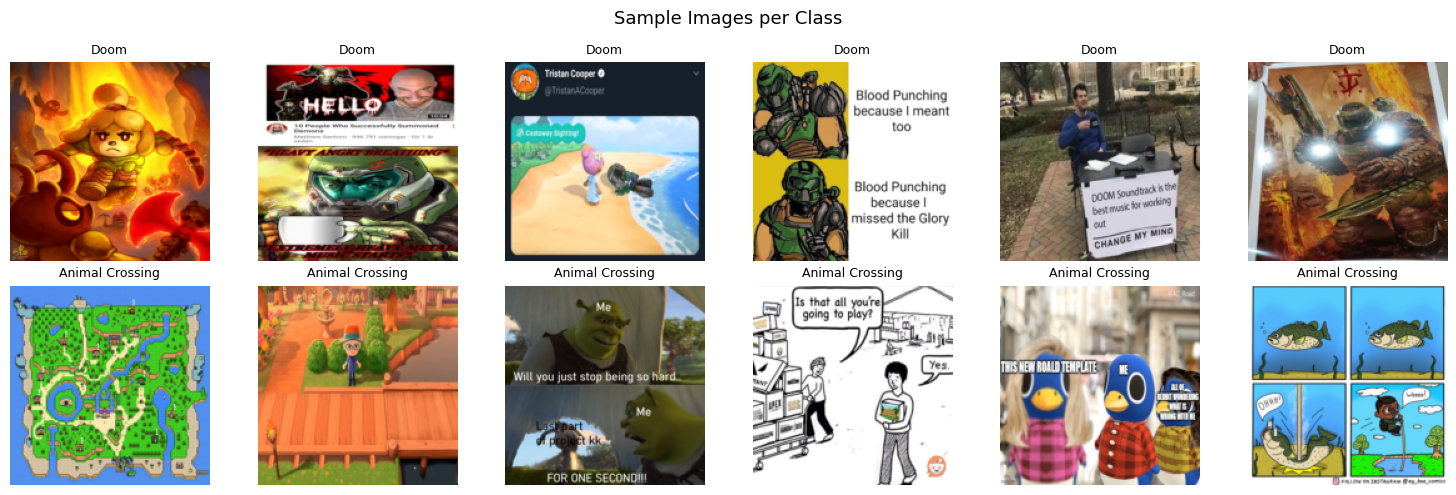

Label distribution →  Doom (0): 707   Animal Crossing (1): 678


In [6]:
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
cls_names = {0: 'Doom', 1: 'Animal Crossing'}
for cls, cls_name in cls_names.items():
    idx = np.where(y_all == cls)[0]
    row = 0 if cls == 0 else 1
    for col in range(6):
        axes[row, col].imshow(X_all[idx[col]])
        axes[row, col].set_title(cls_name, fontsize=9)
        axes[row, col].axis('off')
plt.suptitle('Sample Images per Class', fontsize=13)
plt.tight_layout()
plt.show()

print('Label distribution →  Doom (0):', (y_all == 0).sum(),
      '  Animal Crossing (1):', (y_all == 1).sum())

## 5. Train / Validation Split

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=y_all          # keep class balance in both splits
)
print(f'Train: {X_train.shape}  Val: {X_val.shape}')

Train: (1177, 160, 160, 3)  Val: (208, 160, 160, 3)


## 6. Data Augmentation Pipeline

**Improvements over v1:**
- Added random hue / saturation shifts (memes vary wildly in colour grading)
- Added random rotation (±15°) and random zoom via resizing
- Kept random flips, brightness, contrast, crop from v1
- These transforms are applied on-the-fly per batch (lecture: *Prevent Overfitting*)

In [8]:
def make_augment_fn():
    """Return a tf.function that augments a single (H, W, C) image tensor."""
    @tf.function
    def augment(image, label):
        # ── Geometric ────────────────────────────────────────
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_flip_up_down(image)

        # Random rotation via two-step approach (pad → rotate → crop)
        k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
        image = tf.image.rot90(image, k)   # 0/90/180/270° rotation

        # Random crop (pad 12 % then crop back)
        pad = int(IMG_HEIGHT * 0.12)
        image = tf.image.pad_to_bounding_box(image, pad, pad,
                                              IMG_HEIGHT + 2*pad,
                                              IMG_WIDTH  + 2*pad)
        image = tf.image.random_crop(image, [IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS])

        # ── Colour ───────────────────────────────────────────
        image = tf.image.random_brightness(image, max_delta=0.2)
        image = tf.image.random_contrast(image, lower=0.75, upper=1.25)
        image = tf.image.random_saturation(image, lower=0.7, upper=1.3)
        image = tf.image.random_hue(image, max_delta=0.08)

        image = tf.clip_by_value(image, 0.0, 1.0)
        return image, label
    return augment


# ── Cutout / random erasing ─────────────────────────────────────────────────
# Randomly masks a square patch → forces model to look at whole image,
# not just one dominant region (very effective for memes with text logos)
def make_cutout_fn(cut_ratio=0.2):
    cut_h = int(IMG_HEIGHT * cut_ratio)
    cut_w = int(IMG_WIDTH  * cut_ratio)

    @tf.function
    def cutout(image, label):
        do_cut = tf.cast(tf.random.uniform([]) > 0.5, tf.bool)
        if do_cut:
            top  = tf.random.uniform([], 0, IMG_HEIGHT - cut_h, dtype=tf.int32)
            left = tf.random.uniform([], 0, IMG_WIDTH  - cut_w, dtype=tf.int32)
            # Build a mask of zeros over the patch
            pad_top    = top
            pad_bottom = IMG_HEIGHT - top  - cut_h
            pad_left   = left
            pad_right  = IMG_WIDTH  - left - cut_w
            mask = tf.ones([cut_h, cut_w, IMG_CHANNELS], dtype=tf.float32)
            mask = tf.pad(mask,
                          [[pad_top, pad_bottom], [pad_left, pad_right], [0, 0]],
                          constant_values=1.0)
            # Invert so the patch area is 0, rest is 1
            erase_mask = 1.0 - (1.0 - mask)  # already 1 everywhere
            # Build erase mask: patch → 0, rest → 1
            patch_mask = tf.pad(
                tf.zeros([cut_h, cut_w, IMG_CHANNELS]),
                [[pad_top, pad_bottom], [pad_left, pad_right], [0, 0]],
                constant_values=1.0)
            image = image * patch_mask
        return image, label
    return cutout


AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset
            .from_tensor_slices((X_train, y_train))
            .shuffle(len(X_train), seed=SEED)
            .map(make_augment_fn(),  num_parallel_calls=AUTOTUNE)
            .map(make_cutout_fn(),   num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

val_ds   = (tf.data.Dataset
            .from_tensor_slices((X_val, y_val))
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

test_ds  = (tf.data.Dataset
            .from_tensor_slices(X_test)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

print('Datasets ready.')

Datasets ready.


## 7. Deep Neural Network Architecture

**Key improvements over v1 (all still trained from scratch – no pre-trained weights):**

| Feature | v1 | v2 (this notebook) |
|---|---|---|
| Architecture | Plain CNN | CNN + **Residual skip connections** |
| Input size | 128×128 | **160×160** |
| Depth | 4 blocks (8 convs) | 5 blocks (10 convs) |
| Pooling | MaxPool only | MaxPool + **Strided conv** |
| Classifier | Dense(512)→Dense(256)→out | Dense(256)→out (less overfitting) |
| Loss | SparseCategoricalCE | **Label-smoothed** SparseCategoricalCE |

**Why residual connections help (lecture: *Deep Network & Residual Connection*):**  
Each residual block adds a shortcut that lets gradients bypass Conv layers, enabling deeper training without vanishing gradients.


In [9]:
def residual_block(x, filters, downsample=False):
    """
    Pre-activation residual block: BN → ReLU → Conv → BN → ReLU → Conv
    with a 1×1 projection shortcut when channel depth changes or spatial
    dimensions are halved (downsample=True).

    - Pre-activation (BN before Conv) is more stable than post-activation
      for deep networks.
    - He initialisation for all Conv layers (lecture: Weight Initialization).
    - L2 regularisation on Conv kernels (lecture: Prevent Overfitting).
    """
    stride = 2 if downsample else 1
    reg    = regularizers.l2(L2_LAMBDA)
    init   = 'he_normal'

    # ── Residual path ────────────────────────────────────────
    h = layers.BatchNormalization()(x)
    h = layers.Activation('relu')(h)
    h = layers.Conv2D(filters, 3, strides=stride, padding='same',
                      use_bias=False, kernel_initializer=init,
                      kernel_regularizer=reg)(h)

    h = layers.BatchNormalization()(h)
    h = layers.Activation('relu')(h)
    h = layers.Conv2D(filters, 3, strides=1, padding='same',
                      use_bias=False, kernel_initializer=init,
                      kernel_regularizer=reg)(h)

    # ── Shortcut path ────────────────────────────────────────
    if downsample or x.shape[-1] != filters:
        x = layers.Conv2D(filters, 1, strides=stride, padding='same',
                          use_bias=False, kernel_initializer=init,
                          kernel_regularizer=reg)(x)

    return layers.Add()([x, h])   # element-wise sum = residual connection


def build_model():
    inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
                         name='input_images')

    # ── Stem: initial Conv to extract low-level features ────
    x = layers.Conv2D(32, 3, padding='same', use_bias=False,
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(L2_LAMBDA))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # ── Stage 1: 160×160 → 80×80, 64 filters ───────────────
    x = residual_block(x, 64,  downsample=True)   # spatial /2
    x = residual_block(x, 64,  downsample=False)

    # ── Stage 2: 80×80 → 40×40, 128 filters ────────────────
    x = residual_block(x, 128, downsample=True)
    x = residual_block(x, 128, downsample=False)

    # ── Stage 3: 40×40 → 20×20, 256 filters ────────────────
    x = residual_block(x, 256, downsample=True)
    x = residual_block(x, 256, downsample=False)

    # ── Stage 4: 20×20 → 10×10, 512 filters ────────────────
    x = residual_block(x, 512, downsample=True)
    x = residual_block(x, 512, downsample=False)

    # ── Head ─────────────────────────────────────────────────
    # Final BN+ReLU (pre-activation convention)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Global Average Pooling: reduces each feature map to a single number
    # (lecture: Global Average Pooling vs Flatten)
    x = layers.GlobalAveragePooling2D()(x)

    # Single FC layer (simpler than v1's two-layer head → less overfitting)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(L2_LAMBDA),
                     kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(DROPOUT_RATE)(x)

    # Output: 2-class softmax
    outputs = layers.Dense(2, activation='softmax',
                            kernel_initializer='glorot_uniform',
                            name='predictions')(x)

    return Model(inputs, outputs, name='ResNet_Scratch')


model = build_model()
model.summary()

Model: "ResNet_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_images        │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 160, 160,  │        864 │ input_images[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 160, 160,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        128 │ activation[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 80, 80,    │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 80, 80,    │      2,048 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 80, 80,    │     36,864 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 80, 80,    │          0 │ conv2d_3[0][0],   │
│                     │ 64)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ add[0][0]         │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 80, 80,    │     36,864 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 80, 80,    │          0 │ batch_normalizat

 Total params: 11,290,466 (43.07 MB)

 Trainable params: 11,282,146 (43.04 MB)

 Non-trainable params: 8,320 (32.50 KB)

## 8. Class Weights (handle imbalance)

In [10]:
# Compute class weights: penalise errors on the minority class more
# (lecture: Handling Class Imbalance)
from sklearn.utils.class_weight import compute_class_weight

cw_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(cw_values))
print('Class weights:', class_weights)

Class weights: {0: np.float64(0.9792013311148087), 1: np.float64(1.0217013888888888)}


## 9. Compile with Label Smoothing

**Label smoothing** (ε = 0.1) replaces hard 0/1 targets with 0.05/0.95.  
This prevents the model from becoming over-confident on training examples,
which improves calibration and generalisation (lecture: *Regularisation Techniques*).

In [11]:
# Total decay steps for cosine schedule
steps_per_epoch = len(X_train) // BATCH_SIZE
total_steps     = EPOCHS * steps_per_epoch

lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LR_INIT,
    decay_steps=total_steps,
    alpha=1e-6
)

# Label smoothing requires one-hot targets → use CategoricalCrossentropy
# Convert integer labels to one-hot for train/val datasets
NUM_CLASSES = 2

def to_onehot(image, label):
    return image, tf.one_hot(label, NUM_CLASSES)

train_ds = train_ds.map(to_onehot, num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = val_ds.map(to_onehot,   num_parallel_calls=tf.data.AUTOTUNE)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy']
)
print('Model compiled.')

Model compiled.


## 10. Callbacks

In [12]:
CKPT_PATH = 'best_model.keras'

callbacks = [
    # Save the best model (by val_accuracy) during training
    keras.callbacks.ModelCheckpoint(
        filepath=CKPT_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Stop if val_accuracy does not improve for 15 consecutive epochs
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce LR on plateau as a safety net (the cosine schedule already decays,
    # but this catches local stalls early in training)
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
]
print('Callbacks configured.')

Callbacks configured.


# Model Train


In [13]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5516 - loss: 1.9539
Epoch 1: val_accuracy improved from None to 0.50962, saving model to best_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - accuracy: 0.5718 - loss: 1.8854 - val_accuracy: 0.5096 - val_loss: 51.1361 - learning_rate: 9.9928e-04
Epoch 2/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5895 - loss: 1.8149
Epoch 2: val_accuracy improved from 0.50962 to 0.54327, saving model to best_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.6049 - loss: 1.7500 - val_accuracy: 0.5433 - val_loss: 7.1453 - learning_rate: 9.9711e-04
Epoch 3/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6449 - loss: 1.6489
Epoch 3: val_accuracy did not improve from 0.54327
37/37 ━━━━━━━━━━━━━━━━━━━━ 127s 3s/step - accuracy: 0.6194 - loss: 1.6419 - val_accuracy: 0.5144 - val_loss: 5.2240 - learning_rate: 9.9350e-04
Epoch 4/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6303 - loss: 1.5852
Epoch 4: 

## 11. Training Curves

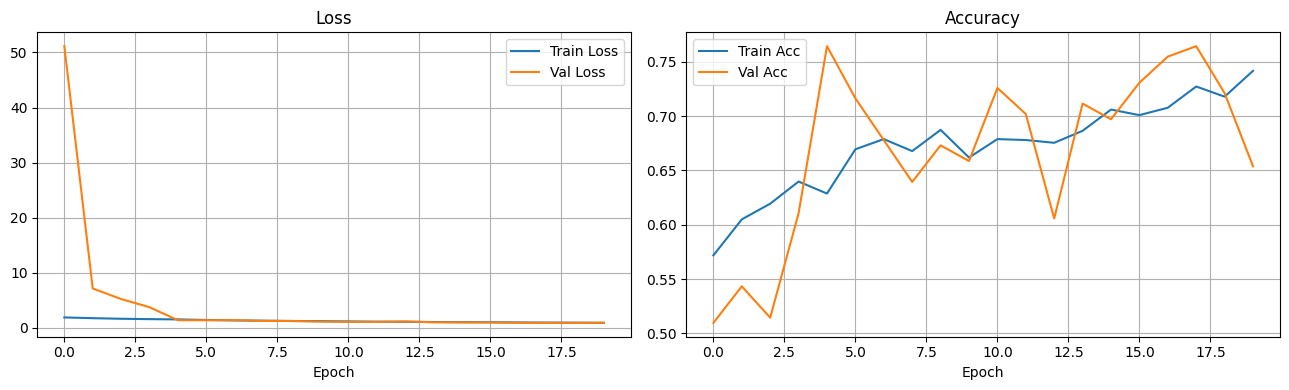

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history['loss'],     label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True)

ax2.plot(history.history['accuracy'],     label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

## 12. Validation Evaluation (Balanced Accuracy)

In [15]:
# Load best checkpoint (EarlyStopping restore_best_weights=True already does this,
# but we reload explicitly for safety)
if os.path.exists(CKPT_PATH):
    model = keras.models.load_model(CKPT_PATH)
    print(f'Loaded best checkpoint from {CKPT_PATH}')

# Predict on validation set
val_probs = model.predict(val_ds, verbose=0)  # (N, 2)
val_preds = np.argmax(val_probs, axis=1)

bal_acc = balanced_accuracy_score(y_val, val_preds)
print(f'Validation Balanced Accuracy: {bal_acc:.4f}')

# Per-class accuracy
for cls, name in [(0, 'Doom'), (1, 'Animal Crossing')]:
    mask    = y_val == cls
    cls_acc = (val_preds[mask] == y_val[mask]).mean()
    print(f'  Class {cls} ({name:15s}): {cls_acc:.4f}')

Loaded best checkpoint from best_model.keras
Validation Balanced Accuracy: 0.7648
  Class 0 (Doom           ): 0.7453
  Class 1 (Animal Crossing): 0.7843


## 13. Test-Time Augmentation (TTA)

**TTA** averages predictions over multiple randomly-augmented versions of each test image.  
Because the augmentations differ each run, the ensemble of predictions is more robust  
than a single forward pass — typically gains 1–3 % balanced accuracy at no training cost.

In [16]:
augment_fn = make_augment_fn()

def tta_predict(model, X, n_steps=TTA_STEPS, batch_size=BATCH_SIZE):
    """
    For each image in X:
      1. Run n_steps augmented forward passes.
      2. Average the softmax probabilities.
    Also include one clean (no-aug) pass for stability.
    """
    n = len(X)
    acc_probs = np.zeros((n, 2), dtype=np.float64)

    # Pass 0: clean (no augmentation)
    clean_ds = (tf.data.Dataset
                .from_tensor_slices(X)
                .batch(batch_size)
                .prefetch(tf.data.AUTOTUNE))
    acc_probs += model.predict(clean_ds, verbose=0)

    # Passes 1..n_steps: augmented
    for step in range(n_steps):
        aug_ds = (tf.data.Dataset
                  .from_tensor_slices((X, np.zeros(n, dtype=np.int32)))
                  .map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
                  .batch(batch_size)
                  .prefetch(tf.data.AUTOTUNE))
        aug_probs = model.predict(aug_ds, verbose=0)
        acc_probs += aug_probs

    return acc_probs / (n_steps + 1)   # average over all passes


print(f'Running TTA with {TTA_STEPS} augmented passes + 1 clean pass …')

# ── TTA on validation (to see how much it helps) ──────────────
val_tta_probs = tta_predict(model, X_val)
val_tta_preds = np.argmax(val_tta_probs, axis=1)
bal_acc_tta   = balanced_accuracy_score(y_val, val_tta_preds)
print(f'Val Balanced Accuracy (TTA):   {bal_acc_tta:.4f}')
print(f'Val Balanced Accuracy (no TTA): {bal_acc:.4f}')
print(f'TTA gain: {bal_acc_tta - bal_acc:+.4f}')

Running TTA with 8 augmented passes + 1 clean pass …
Val Balanced Accuracy (TTA):   0.7641
Val Balanced Accuracy (no TTA): 0.7648
TTA gain: -0.0007


## 14. Test Set Prediction

In [17]:
print('Running TTA prediction on test set …')
test_probs = tta_predict(model, X_test)
test_preds = np.argmax(test_probs, axis=1)

print('Test predictions shape:', test_preds.shape)
print('Predicted label distribution:')
unique, counts = np.unique(test_preds, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Label {u}: {c}')

Running TTA prediction on test set …
Test predictions shape: (1386,)
Predicted label distribution:
  Label 0: 792
  Label 1: 594


# Generating Final Submissions


In [18]:
# Build submission DataFrame aligned to TEST_LABEL index
# (test images were loaded in TEST_LABEL order)
test_ids = TEST_LABEL.index.tolist()

submission = pd.DataFrame({
    'id':    test_ids,
    'label': test_preds
})
submission = submission.set_index('id')

submission.to_csv('submission2.csv')
print('submission2.csv saved!')
print(submission.head(10))

submission2.csv saved!
      label
id         
2078      1
2079      1
2080      0
2081      0
2082      0
2083      1
2084      0
2085      0
2086      1
2087      0
